# 3 - Entrenamiento de Modelos y Exportación ONNX (FinanceAI)

1. Simulación > 2. EDA > **3. Entrenamiento**


### Preparación del Entorno
Importar librerías y cargar los archivos de datos limpios generados en el primer cuaderno. Separar la información en variables para entrenamiento: (X) (Y)

In [1]:
import pandas as pd

import nltk
from nltk.corpus import stopwords
import certifi
import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
nltk.download('stopwords', quiet=True)
domain_stopwords = ['compra', 'compras', 'pago', 'pagos', 'gasto', 'gastos', 'transferencia', 'transferencias', 'deposito', 'factura', 'boleta', 'ticket', 'cuota', 'servicio', 'adquisicion']
spanish_stop_words = stopwords.words('spanish') + domain_stopwords
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
import json
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from skl2onnx import to_onnx
from skl2onnx.common.data_types import StringTensorType, FloatTensorType

SEED = 42


## 1. Carga de Datos + splits
*   **Para Perfiles:** Corte transversal.
*   **Para Transacciones (NLP):** Corte temporal. El modelo entrena con el historial de Ene-Ago y se evalúa de manera ciega sobre los gastos del futuro (Nov-Dic).

In [2]:
df_usr = pd.read_csv('data/usuarios.csv')
df_txn = pd.read_csv('data/transacciones.csv')

# splits para usuarios (_u)
train_u = df_usr[df_usr['split'] == 'train'].copy()
val_u = df_usr[df_usr['split'] == 'val'].copy()
test_u = df_usr[df_usr['split'] == 'test'].copy()

# splits para transacciones (_t)
train_t = df_txn[df_txn['split'] == 'train'].copy()
val_t = df_txn[df_txn['split'] == 'val'].copy()
test_t = df_txn[df_txn['split'] == 'test'].copy()


print(f"Revisión:\nUsuarios (Train/Val/Test): {len(train_u)} / {len(val_u)} / {len(test_u)}")
print(f"Transacciones (Train/Val/Test): {len(train_t)} / {len(val_t)} / {len(test_t)}")

Revisión:
Usuarios (Train/Val/Test): 1117 / 319 / 364
Transacciones (Train/Val/Test): 159501 / 40302 / 40197


## 2. Modelo 1: Perfiles financieros
Entrenamiento de un árbol de decisión basado en ingresos, nivel de endeudamiento y frecuencia de ahorro (preprocesada numéricamente para ONNX).

A)--- Reporte en VAL (Ajuste) ---
                precision    recall  f1-score   support

En observacion       1.00      1.00      1.00       137
     En riesgo       1.00      1.00      1.00        72
     Saludable       1.00      1.00      1.00       110

      accuracy                           1.00       319
     macro avg       1.00      1.00      1.00       319
  weighted avg       1.00      1.00      1.00       319


B)--- Reporte en TEST (calificación final) ---
                precision    recall  f1-score   support

En observacion       1.00      1.00      1.00       156
     En riesgo       1.00      1.00      1.00        80
     Saludable       1.00      1.00      1.00       128

      accuracy                           1.00       364
     macro avg       1.00      1.00      1.00       364
  weighted avg       1.00      1.00      1.00       364



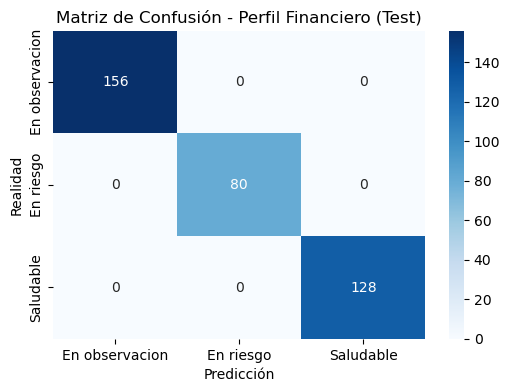

In [3]:
# Preprocesamiento (conversión numérica compatible con java)
mapeo_ahorro = {'Ninguna': 0.0, 'Baja': 1.0, 'Media': 2.0, 'Alta': 3.0}

# Servir los datos para el entrenamiento
# Preparar los datos brutos del CSV para que el algoritmo matemático pueda digerirlos antes de entrenar el modelo
def prepare_features(df):
    df_prep = df.copy() # Hace una copia de seguridad de la tabla de datos para no arruinar el archivo original
    df_prep['ahorro_num'] = df_prep['frecuencia_ahorro'].map(mapeo_ahorro) # traduce palabras a números
    return df_prep[['ingreso_mensual', 'nivel_endeudamiento', 'ahorro_num']], df_prep['perfil_financiero'] # separan la tabla en dos partes y devuelve features y labels

X_train_u, y_train_u = prepare_features(train_u)
X_val_u, y_val_u = prepare_features(val_u)
X_test_u, y_test_u = prepare_features(test_u)

# Entrenamiento (class_weight='balanced' para priorizar detección de 'en riesgo')
profiler_model = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=SEED) # subido el max depth de 5 a 8
profiler_model.fit(X_train_u, y_train_u)

# Evaluación ciega sobre set de validación y test
y_val_pred = profiler_model.predict(X_val_u)
y_test_pred = profiler_model.predict(X_test_u)

print("A)--- Reporte en VAL (Ajuste) ---")
print(classification_report(y_val_u, y_val_pred))

print("\nB)--- Reporte en TEST (calificación final) ---")
print(classification_report(y_test_u, y_test_pred))# Graficar matriz de confusión del perfil financiero
cm_prof = confusion_matrix(y_test_u, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_prof, annot=True, fmt='d', cmap='Blues', xticklabels=profiler_model.classes_, yticklabels=profiler_model.classes_)
plt.title('Matriz de Confusión - Perfil Financiero (Test)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()


### Nota sobre las métricas perfectas del perfilador financiero

El modelo de perfilado obtiene **1.00 en precisión, recall y F1-Score** en todas las clases. Esto **no indica sobreajuste** (*overfitting*); se explica por la naturaleza de los datos sintéticos:

Los perfiles financieros (`Saludable`, `En observación`, `En riesgo`) fueron generados en el notebook de simulación mediante **reglas determinísticas** aplicadas sobre exactamente las mismas tres variables que alimentan al modelo: `ingreso_mensual`, `nivel_endeudamiento` y `frecuencia_ahorro`. El árbol de decisión simplemente reproduce esas fronteras de clasificación sin ambigüedad.

En un entorno de producción con datos bancarios reales, las fronteras entre perfiles no serían tan nítidas (un mismo nivel de ingreso puede corresponder a perfiles diferentes según el contexto del usuario), y las métricas del modelo reflejarían esa complejidad. Los datos sintéticos funcionan como un *placeholder* controlado para validar el pipeline completo de entrenamiento, exportación ONNX e inferencia en el backend de Java.


## 3. Modelo 2: NLP para categorización de transacciones

### 3.1. Empaquetar los pasos en un `Pipeline`
**Mejora de Stopwords de Dominio**: Hemos enriquecido el diccionario estándar de `spanish_stop_words` con términos transaccionales genéricos (`compra`, `pago`, `transferencia`, etc.). Esto evita que palabras altamente frecuentes y sin valor discriminativo sesguen el modelo hacia la categoría *Inversión* u otras.

En NLP (Procesamiento de Lenguaje Natural), transformar el texto a números (`TfidfVectorizer`) y aplicar la fórmula matemática (`LogisticRegression`) son dos pasos secuenciales inseparables.
En lugar de entrenar cada uno por separado, los empaquetamos en un único objeto llamado `Pipeline`:
```python
nlp_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=spanish_stop_words)),
    ('clf', LogisticRegression(random_state=SEED, class_weight='balanced', max_iter=1000, tol=1e-3))
])
```
*Didáctica*: Le dimos un "apodo" a cada paso (`'tfidf'` y `'clf'`). Esto es fundamental para el siguiente paso, porque así le indicaremos a la grilla qué parámetro pertenece a qué componente.

### 3.2. Construir la Grilla de Opciones (`param_grid`)
Aquí definimos el espacio de búsqueda. **Mejora de Robustez (`max_df`)**: Hemos introducido el hiperparámetro `tfidf__max_df`. Este valor le indica al modelo que ignore cualquier palabra que aparezca en más de un porcentaje determinado de los documentos (ej: 0.75 significa 75%). Es un filtro estadístico poderoso contra el ruido de dominio.

 Creamos un diccionario en Python dictando exactamente qué valores queríamos que la máquina probará, evitando que adivinemos a ojo.
```python
param_grid = {
    'tfidf__max_features': [1000, 2000],
    'clf__C': [0.1, 1.0, 10.0],
    'clf__max_iter': [500, 1000]
}
```
*Didáctica*: Nota la sintaxis de doble guion bajo (`__`). Esto le dice a Python: *"entra al paso llamado `tfidf` y modifica su `max_features`"*. Multiplicando las opciones (2 x 3 x 2), generamos **12 combinaciones posibles**.

### 3.3. Instanciar el Motor de Búsqueda
Le pasamos nuestro Pipeline vacío y nuestras 12 combinaciones al motor `GridSearchCV` de *scikit-learn*:
```python
grid_search = GridSearchCV(
    estimator=nlp_pipeline,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)
```
*Didáctica de Parámetros:*
* **`cv=3`**: Activa la Validación Cruzada (*Cross Validation*). En lugar de evaluar cada combinación una sola vez, divide los datos de entrenamiento en 3 bloques. Entrena en 2, evalúa en 1, y repite rotando los bloques. Como hay 12 combinaciones y 3 rotaciones, el sistema realiza internamente **36 entrenamientos completos**.
* **`n_jobs=-1`**: Le ordena a Python exprimir al máximo tu procesador, usando todos los núcleos disponibles en paralelo para acelerar los 36 cálculos.

### 3.4. Lanzar el Entrenamiento y Extraer el Ganador
Una vez configurado, simplemente le entregamos los datos de entrenamiento (las palabras y las etiquetas correctas) y esperamos que encuentre el modelo óptimo.
```python
grid_search.fit(X_train_t, y_train_t)
best_model = grid_search.best_estimator_
nlp_pipeline = best_model
```
*Didáctica*: El método `.fit()` ejecuta la fuerza bruta inteligente. Una vez termina, el objeto `grid_search` se queda guardando al "campeón absoluto" en su variable interna `best_estimator_`. Extraemos ese modelo campeón (que ya tiene los pesos matemáticos ajustados y la exactitud del ~91%) y lo renombramos a `nlp_pipeline`.



In [4]:
# Preparación de los textos de entrada. El pipeline procesa arreglos 1D en Python.
X_train_t = train_t['descripcion']
y_train_t = train_t['categoria']

X_val_t = val_t['descripcion']
y_val_t = val_t['categoria']

X_test_t = test_t['descripcion']
y_test_t = test_t['categoria']

# Pipeline Completo
# Entrenamiento NLP con GridSearchCV - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
print("Configurando el Pipeline y GridSearchCV...")
# 1. Pipeline Base: Define el flujo de datos secuencial
# Primero TRANSFORMA EL TEXTO A NÚMEROS (TF-IDF) y luego aplica el modelo (LogisticRegression)
nlp_pipeline = Pipeline([
    # Se filtran las 'stop_words' para evitar que conectores o artículos generen ruido
    ('tfidf', TfidfVectorizer(stop_words=spanish_stop_words)),
    # Modelo clasificador con semilla fija (SEED) para que el resultado sea reproducible
    ('clf', LogisticRegression(random_state=SEED, class_weight='balanced', max_iter=1000, tol=1e-3))
])

# Definimos la grilla de hiperparámetros
# 2. Espacio de Búsqueda (Grid): Evita el uso de "parámetros mágicos"
# Le decimos al algoritmo qué valores probar para encontrar matemáticamente al ganador.
param_grid = {
    # Ampliado a 2000, 3000 y 4000 para el vocabulario regional extendido
    'tfidf__max_features': [2000, 3000, 4000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # Unigramas y bigramas
    'tfidf__max_df': [0.75, 0.85],
    'clf__C': [0.5, 1.0, 5.0],
    'clf__max_iter': [1000]
}

print("Iniciando la búsqueda exhaustiva de hiperparámetros (esto puede tardar unos minutos)...")
# 3. Motor de Búsqueda y Validación Cruzada
# Stratified K-Fold (Validación Cruzada Estratificada de 3 pliegues), garantizando la misma 
# proporción de categorías en cada uno de los 3 bloques.
grid_search = GridSearchCV(nlp_pipeline, param_grid, cv=3, n_jobs=-1, verbose=1)
# 4. Ejecución del Entrenamiento Masivo
# Aquí ocurren los 36 ajustes internos (12 combinaciones * 3 divisiones de datos)
grid_search.fit(X_train_t, y_train_t)

print("Mejores parámetros encontrados por la validación cruzada:")
print(grid_search.best_params_)

# 5. Extracción y Reasignación del Modelo Óptimo
# Extraemos el mejor modelo ya entrenado de toda la búsqueda
best_model = grid_search.best_estimator_
# Sobrescribimos la variable inicial. 
# Esto es CRÍTICO para que la exportación a ONNX de la Sección 4 lea un modelo con los "pesos" ajustados.
nlp_pipeline = best_model  # Reasignar para compatibilidad con exportación ONNX y metadatos

print("Evaluando el modelo óptimo con distintos umbrales de probabilidad...")
def evaluar_con_umbral(modelo, X, y_true, umbral):
    probas = modelo.predict_proba(X)
    clases = modelo.classes_
    y_pred = []
    
    for p in probas:
        idx_max = np.argmax(p)
        if p[idx_max] >= umbral:
            y_pred.append(clases[idx_max])
        else:
            y_pred.append("Revision Manual")
            
    print(f"\n--- Reporte NLP con Umbral >= {umbral} ---")
    from sklearn.metrics import classification_report
    print(classification_report(y_true, y_pred, zero_division=0))

umbrales = [0.4, 0.6, 0.8]
print("\n--- Resultados en Validación (ciego para el modelo) ---")
for u in umbrales:
    evaluar_con_umbral(best_model, X_val_t, y_val_t, u)

print("\n--- Resultados en Test (calificación final) ---")
for u in umbrales:
    evaluar_con_umbral(best_model, X_test_t, y_test_t, u)


Configurando el Pipeline y GridSearchCV...
Iniciando la búsqueda exhaustiva de hiperparámetros (esto puede tardar unos minutos)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Mejores parámetros encontrados por la validación cruzada:
{'clf__C': 1.0, 'clf__max_iter': 1000, 'tfidf__max_df': 0.75, 'tfidf__max_features': 4000, 'tfidf__ngram_range': (1, 1)}
Evaluando el modelo óptimo con distintos umbrales de probabilidad...

--- Resultados en Validación (ciego para el modelo) ---

--- Reporte NLP con Umbral >= 0.4 ---
                   precision    recall  f1-score   support

     Alimentacion       0.99      0.98      0.99      6115
        Educacion       0.99      1.00      1.00      2053
Electrodomesticos       0.88      0.96      0.92      2046
        Inversion       1.00      1.00      1.00      4040
             Ocio       1.00      0.99      0.99      4083
  Revision Manual       0.00      0.00      0.00         0
            Salud       1.00      1.00      1.00 

## 4. Exportación ONNX y Contrato de Metadatos
Para garantizar la interoperabilidad con Spring Boot, se serializan los modelos y se genera un contrato JSON que especifique los tipos de datos de entrada/salida.

Se exportan ambos modelos terminados al formato universal ONNX. Este estándar empaqueta las matemáticas en un solo archivo, lo que permite que el equipo de backend pueda cargar la IA directamente en java sin necesidad de programar en python para producción.

In [5]:
os.makedirs('models', exist_ok=True)
os.makedirs('../shared-models', exist_ok=True)

# Exportar modelo perfil (espera matriz bidimensional de 3 floats)
initial_type_prof = [('float_input', FloatTensorType([None, 3]))]
onnx_prof = to_onnx(profiler_model, initial_types=initial_type_prof, target_opset=12)

# Exportar modelo NLP (espera array de strings)
# skl2onnx requiere shape [None, 1] para inputs tipo string desde pipelines
initial_type_nlp = [('string_input', StringTensorType([None, 1]))]
onnx_nlp = to_onnx(nlp_pipeline, initial_types=initial_type_nlp, target_opset=12)

for path in ['../shared-models/', 'models/']:
    try:
        with open(f"{path}modelo_perfil.onnx", 'wb') as f:
            f.write(onnx_prof.SerializeToString())
        with open(f"{path}modelo_transacciones.onnx", 'wb') as f:
            f.write(onnx_nlp.SerializeToString())
    except PermissionError:
        print(f"Aviso: Sin permisos de escritura en {path}, omitiendo...")

print("Modelos exportados a shared-models/ y models/.")


Modelos exportados a shared-models/ y models/.


In [6]:
# Creación del metadata.json
# Se registran dinámicamente las clases del modelo para no codificarlas fijos (hardcode) en Java

metadata = {
    "model_version": "2.0.0",
    "categories": list(nlp_pipeline.classes_), 
    "profiles": list(profiler_model.classes_), 
    "transacciones_model": {
        "onnx_input_name": "string_input",
        "onnx_output_name": "output_label",
        "categories": list(nlp_pipeline.classes_)
    },
    "perfil_model": {
        "onnx_input_name": "float_input",
        "onnx_output_name": "output_label",
        "profiles": list(profiler_model.classes_)
    }
}

for path in ['../shared-models/', 'models/']:
    try:
        with open(f"{path}metadata.json", "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2, ensure_ascii=False)
    except PermissionError:
        print(f"Aviso: Sin permisos de escritura en {path}, omitiendo...")

print("Contrato de Metadatos creado y exportado:")
print(json.dumps(metadata, indent=2))


Contrato de Metadatos creado y exportado:
{
  "model_version": "2.0.0",
  "categories": [
    "Alimentacion",
    "Educacion",
    "Electrodomesticos",
    "Inversion",
    "Ocio",
    "Salud",
    "Servicios",
    "Transporte",
    "Vestimenta",
    "Vivienda"
  ],
  "profiles": [
    "En observacion",
    "En riesgo",
    "Saludable"
  ],
  "transacciones_model": {
    "onnx_input_name": "string_input",
    "onnx_output_name": "output_label",
    "categories": [
      "Alimentacion",
      "Educacion",
      "Electrodomesticos",
      "Inversion",
      "Ocio",
      "Salud",
      "Servicios",
      "Transporte",
      "Vestimenta",
      "Vivienda"
    ]
  },
  "perfil_model": {
    "onnx_input_name": "float_input",
    "onnx_output_name": "output_label",
    "profiles": [
      "En observacion",
      "En riesgo",
      "Saludable"
    ]
  }
}


In [7]:
# Prueba de score en transacciones
# Durante el proceso de entrenamiento y cruzamiento de los datos (los 3 folds), el modelo debe ser 
# capaz de predecir correctamente la categoría de transacciones.
# debe demostrar que el modelo es robusto, ha generalizado correctamente y está libre de sobreajuste
print(f"Mejor Score (Accuracy en validación cruzada): {grid_search.best_score_:.4f}")

Mejor Score (Accuracy en validación cruzada): 0.9872


---

## Prueba ONNX categorías

import onnxruntime as ort
import numpy as np

# Ya no necesitamos cargar el metadata.json porque ONNX ya sabe las palabras
session = ort.InferenceSession("../shared-models/modelo_transacciones.onnx")
input_name = session.get_inputs()[0].name

print(" Modelo ONNX cargado. Escribe una transacción para probar su inteligencia.")
print("Escribe 'salir' para terminar.\n")

while True:
    texto = input(" Ingresa un gasto (ej. 'compra super', 'cuota osde'): ")
    
    if texto.lower() == 'salir':
        break
        
    # Convertir el texto al formato matricial que espera ONNX
    input_data = np.array([[texto]], dtype=object)
    
    # Hacer la inferencia
    resultado = session.run(None, {input_name: input_data})
    
    # Como el modelo ya escupe el texto directo, simplemente lo imprimimos
    categoria = resultado[0][0]
    
    print(f" Inteligencia Artificial dice: {categoria}\n")

## Prueba de ONNX perfiles

* **Caso negativo:** Ingreso 1500, Deuda 50, Ahorro Ninguna. (Debería dar 'En riesgo').
* **Caso ideal:** Ingreso 4000, Deuda 15, Ahorro Alta. (Debería dar 'Saludable').
* **Caso engañoso:** Ingreso 5000 (mucho dinero), pero deuda 60 (gasta muchísimo en alquiler), ahorro 'Baja'. (El modelo debería ignorar que gana mucho dinero y enviarlo a 'En riesgo' por su mala gestión).

import onnxruntime as ort
import numpy as np

# Cargar el "cerebro" ONNX del perfilador
session_perfil = ort.InferenceSession("../shared-models/modelo_perfil.onnx")
input_name_perfil = session_perfil.get_inputs()[0].name

print(" Modelo de Perfilado ONNX cargado.")
print("Simulemos la economía de un usuario. Escribe 'salir' en cualquier momento para terminar.\\n")

# Diccionario interno que usa tu modelo para entender el texto del ahorro
mapeo_ahorro = {'ninguna': 0.0, 'baja': 1.0, 'media': 2.0, 'alta': 3.0}

while True:
    ingreso = input(" 1. Ingreso mensual (ej. 2500): ")
    if ingreso.lower() == 'salir': break
        
    deuda = input(" 2. Nivel de endeudamiento % (ej. 45 para 45%): ")
    if deuda.lower() == 'salir': break
        
    ahorro = input(" 3. Hábito de ahorro (Ninguna, Baja, Media, Alta): ").lower()
    if ahorro == 'salir': break

    try:
        # Convertir los inputs humanos a números flotantes
        ingreso_float = float(ingreso)
        deuda_float = float(deuda)
        ahorro_float = mapeo_ahorro.get(ahorro, 0.0) # Si escribe mal, asume Ninguna
        
        # ONNX exige una matriz 2D de tipo float32 estricto
        input_data = np.array([[ingreso_float, deuda_float, ahorro_float]], dtype=np.float32)
        
        # Hacer la inferencia
        resultado = session_perfil.run(None, {input_name_perfil: input_data})
        
        # Extraer el veredicto
        perfil_asignado = resultado[0][0]
        
        print(f"\n Diagnóstico de la IA: Usuario {perfil_asignado}\n")
        print("-" * 40)
        
    except ValueError:
        print("\n Error: Asegúrate de ingresar números válidos en Ingreso y Deuda.\n")